# CSIRO Image2Biomass: Model Comparison

Comprehensive comparison of all models across all notebooks:
- Tabular (local only): Constant Baseline, Ridge, LightGBM
- CNN: Custom CNN, Fine-tuned ResNet18
- ViT: Custom ViT, Fine-tuned ViT-B/16
- Combined (local only): Fusion (ViT + Tabular)

Includes summary tables, bar charts, training curves, per-target breakdowns,
parity plots, residual analysis, and failure case visualization.

In essence, our Kaggle submission would be generated from the best image-only model since
the test set does not include tabular features.

Note: For this document, all graph syntax was created with the help of Generative AI.

## 0. Imports

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
np.random.seed(2025)

## 1. Load results from all notebooks

In [2]:
from google.colab import drive
drive.mount('/content/drive')

RESULTS_DIR = Path("/content/drive/MyDrive/biomass_results")

TARGETS = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
TARGET_WEIGHTS = {"Dry_Green_g": 0.1, "Dry_Dead_g": 0.1, "Dry_Clover_g": 0.1,
                  "GDM_g": 0.2, "Dry_Total_g": 0.5}

def load_pkl(name):
    path = RESULTS_DIR / name
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    else:
        print(f"WARNING: {path} not found — run that notebook first!")
        return None

tabular_res  = load_pkl("tabular_results.pkl")
cnn_res      = load_pkl("cnn_results.pkl")
vit_res      = load_pkl("vit_results.pkl")
combined_res = load_pkl("combined_results.pkl")

print("Results loaded.")

Mounted at /content/drive
Results loaded.


## 2. Weighted R² function

In [3]:
def weighted_r2(y_true_mat, y_pred_mat):
    y_true = np.asarray(y_true_mat, dtype=np.float64)
    y_pred = np.asarray(y_pred_mat, dtype=np.float64)
    N = y_true.shape[0]
    w_vec = np.array([TARGET_WEIGHTS[t] for t in TARGETS], dtype=np.float64)
    w = np.tile(w_vec, N)
    yt = y_true.ravel(); yp = y_pred.ravel()
    wsum = w.sum()
    ybar = (w * yt).sum() / wsum
    ss_res = (w * (yt - yp) ** 2).sum()
    ss_tot = (w * (yt - ybar) ** 2).sum()
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

## 3. Build master summary table

In [4]:
all_models = []
category_map = {}

for label, res, cat in [
    ("tabular", tabular_res, "Tabular (local only)"),
    ("cnn", cnn_res, "CNN"),
    ("vit", vit_res, "ViT"),
    ("combined", combined_res, "Combined (local only)"),
]:
    if res is None:
        continue
    for name, data in res["models"].items():
        if "Ablation" in name:
            continue
        all_models.append({
            "model": name,
            "category": cat,
            "test_weighted_R2": data["test_weighted_r2"],
            "can_submit": cat in ("CNN", "ViT"),
        })
        category_map[name] = cat

summary_df = pd.DataFrame(all_models)
summary_df = summary_df.sort_values("test_weighted_R2", ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

                 model              category  test_weighted_R2  can_submit
              LightGBM  Tabular (local only)          0.837255       False
    Ridge (alpha=0.01)  Tabular (local only)          0.674643       False
   ViT-B/16 fine-tuned                   ViT          0.589443        True
   ResNet18 fine-tuned                   CNN          0.565345        True
            Custom CNN                   CNN          0.458950        True
            Custom ViT                   ViT          0.436188        True
Fusion (ViT + Tabular) Combined (local only)          0.394447       False
     Constant Baseline  Tabular (local only)          0.212215       False


As we can see, the models that utilize tabular data have the best results on the defined evaluation mark, however they are not usable for submission. Of the vision models, we see that the fine tuned ViT performs the best, while the Fusion model performs worse than any of the singular modality models.

## 4. Overall comparison bar chart

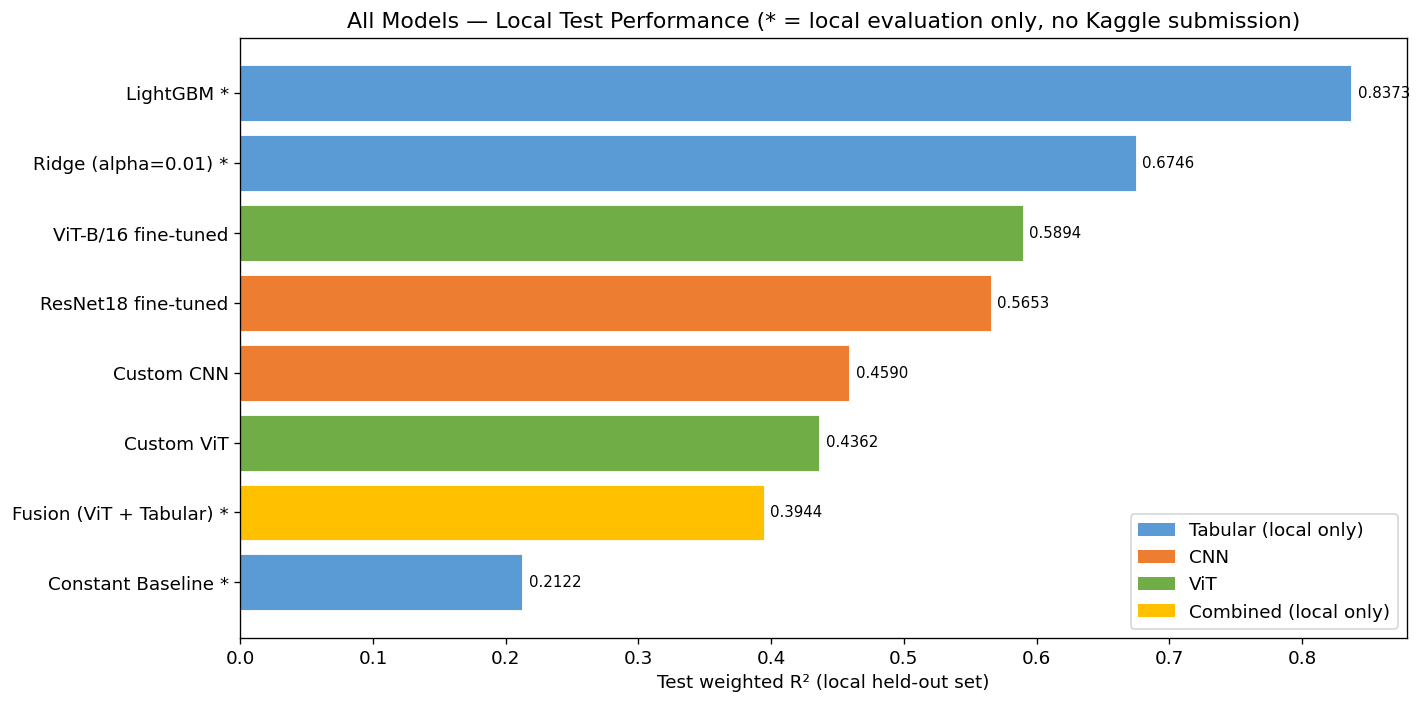

In [5]:
cat_colors = {
    "Tabular (local only)":  "#5B9BD5",
    "CNN":                   "#ED7D31",
    "ViT":                   "#70AD47",
    "Combined (local only)": "#FFC000",
}

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    range(len(summary_df)),
    summary_df["test_weighted_R2"],
    color=[cat_colors.get(c, "#999") for c in summary_df["category"]],
    edgecolor="white", linewidth=0.5
)
ax.set_yticks(range(len(summary_df)))
labels = []
for _, row in summary_df.iterrows():
    suffix = "" if row["can_submit"] else " *"
    labels.append(row["model"] + suffix)
ax.set_yticklabels(labels)
ax.set_xlabel("Test weighted R² (local held-out set)")
ax.set_title("All Models — Local Test Performance (* = local evaluation only, no Kaggle submission)")
ax.invert_yaxis()

for i, v in enumerate(summary_df["test_weighted_R2"]):
    ax.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

legend_elements = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()
                   if cat in summary_df["category"].values]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout(); plt.show()

This table results in the same discussion as we had above, but formatted in an easier-to-understand manner.

## 5. Per-target R² breakdown

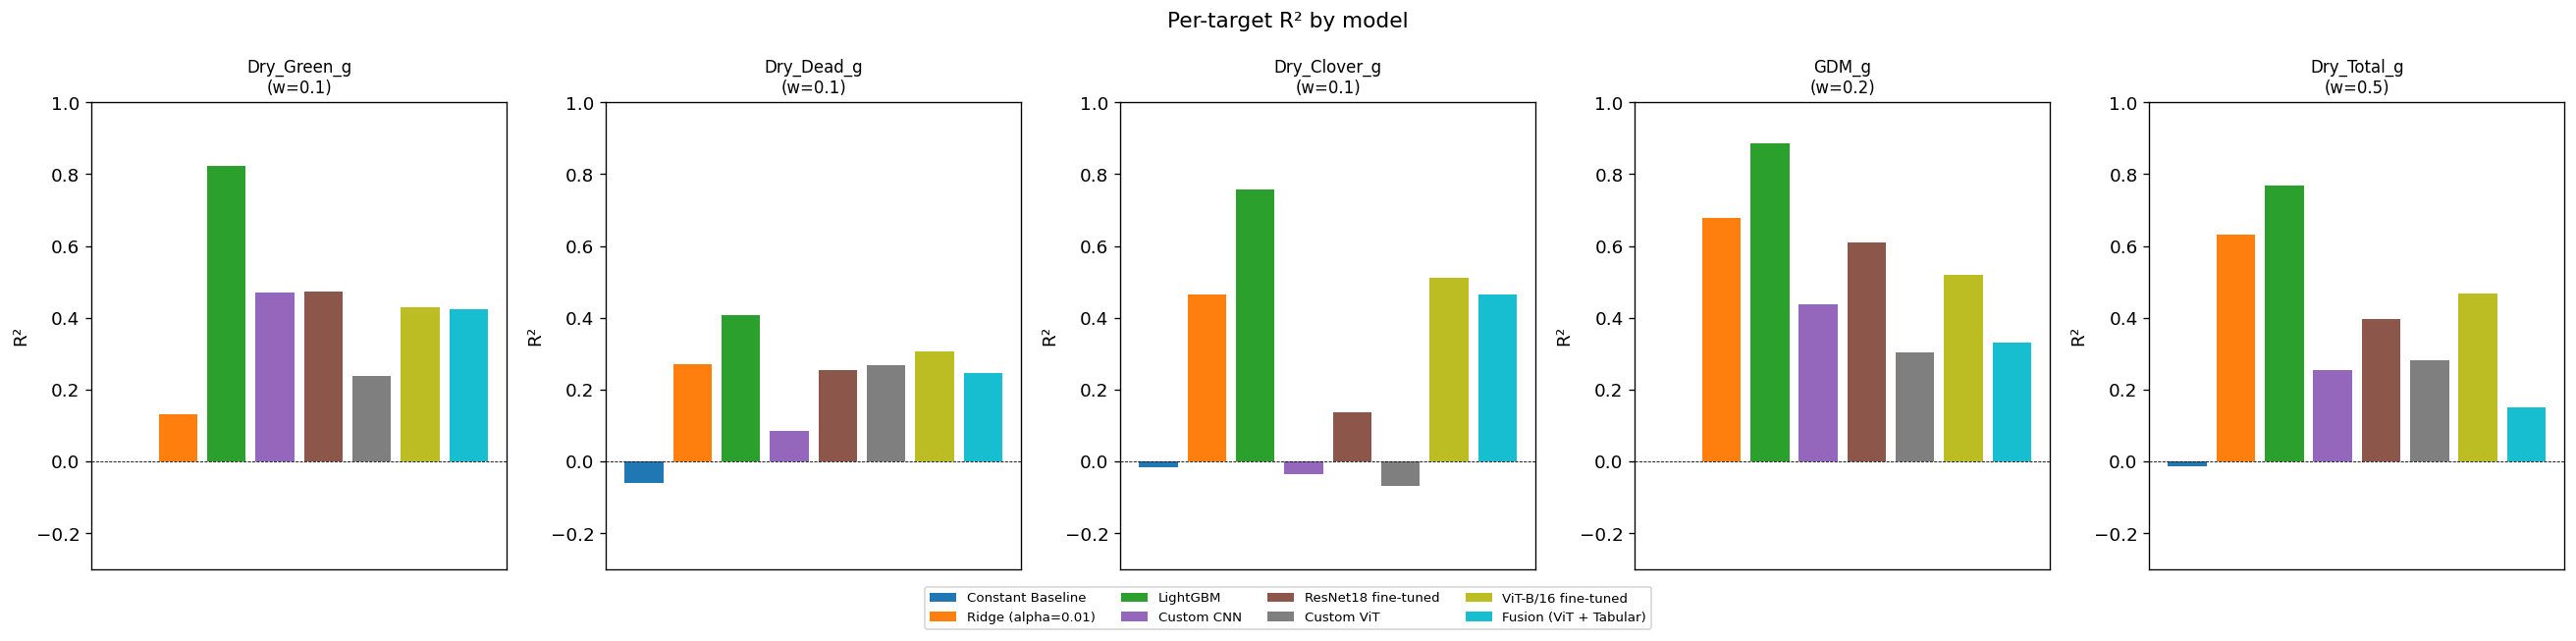

In [15]:
per_target_data = {}
for label, res in [("tabular", tabular_res), ("cnn", cnn_res), ("vit", vit_res), ("combined", combined_res)]:
    if res is None: continue
    for name, data in res["models"].items():
        if "Ablation" in name: continue
        if data.get("per_target") is not None:
            pt = data["per_target"]
            if isinstance(pt, pd.DataFrame):
                per_target_data[name] = pt[pt["target"] != "OVERALL_weighted_R2"]

if per_target_data:
    model_names = list(per_target_data.keys())
    colors_list = plt.cm.tab10(np.linspace(0, 1, min(10, len(model_names))))

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    x = np.arange(len(model_names))

    for k, (ax, t) in enumerate(zip(axes, TARGETS)):
        r2_vals = []
        for name in model_names:
            row = per_target_data[name][per_target_data[name]["target"] == t]
            r2_vals.append(float(row["R2"].values[0]) if len(row) > 0 else 0)
        ax.bar(x, r2_vals, color=colors_list[:len(model_names)])
        ax.set_title(f"{t}\n(w={TARGET_WEIGHTS[t]})", fontsize=10)
        ax.set_ylabel("R²"); ax.set_ylim(-0.3, 1.0)
        ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
        ax.set_xticks([])

    legend_elements = [Patch(facecolor=colors_list[i], label=n) for i, n in enumerate(model_names)]
    fig.legend(handles=legend_elements, loc="lower center", ncol=min(4, len(model_names)),
               bbox_to_anchor=(0.5, -0.08), fontsize=8)
    plt.suptitle("Per-target R² by model", fontsize=13)
    plt.tight_layout(); plt.show()

In general, we see that all of the models have poor performance for predicting the Dry_Dead_g target. For Dry_Clover_g, we observe high variabiklity, where the Custom CNN, Custom ViT, and fine-tuned ResNet modelhave poor performance while the tabular models, fusion model, and ViT perform well. On the whole, we see that the LightGBM model is strictly better than all the models across all targets, which motivated exploration of using vision models to predict the features used in the LightGBM.

## 6. Training curves comparison

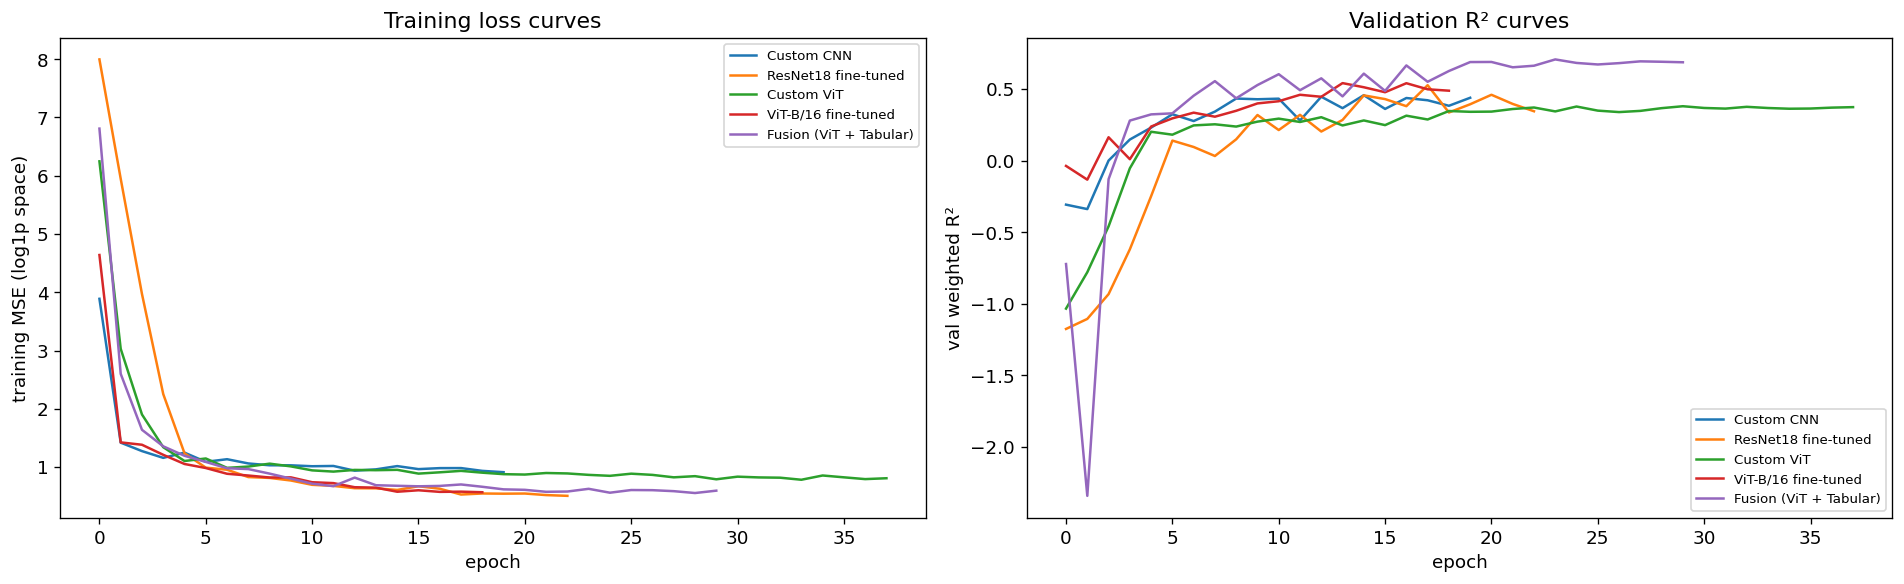

In [16]:
curves = {}
for label, res in [("tabular", tabular_res), ("cnn", cnn_res), ("vit", vit_res), ("combined", combined_res)]:
    if res is None: continue
    for name, data in res["models"].items():
        if "Ablation" in name: continue
        if data.get("val_score") and data["val_score"]:
            curves[name] = data

if curves:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    for name, data in curves.items():
        if data.get("train_loss"):
            ax.plot(data["train_loss"], label=name)
    ax.set_xlabel("epoch"); ax.set_ylabel("training MSE (log1p space)")
    ax.set_title("Training loss curves"); ax.legend(fontsize=8)

    ax = axes[1]
    for name, data in curves.items():
        ax.plot(data["val_score"], label=name)
    ax.set_xlabel("epoch"); ax.set_ylabel("val weighted R²")
    ax.set_title("Validation R² curves"); ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()

## 7. Parity plots — best model per category

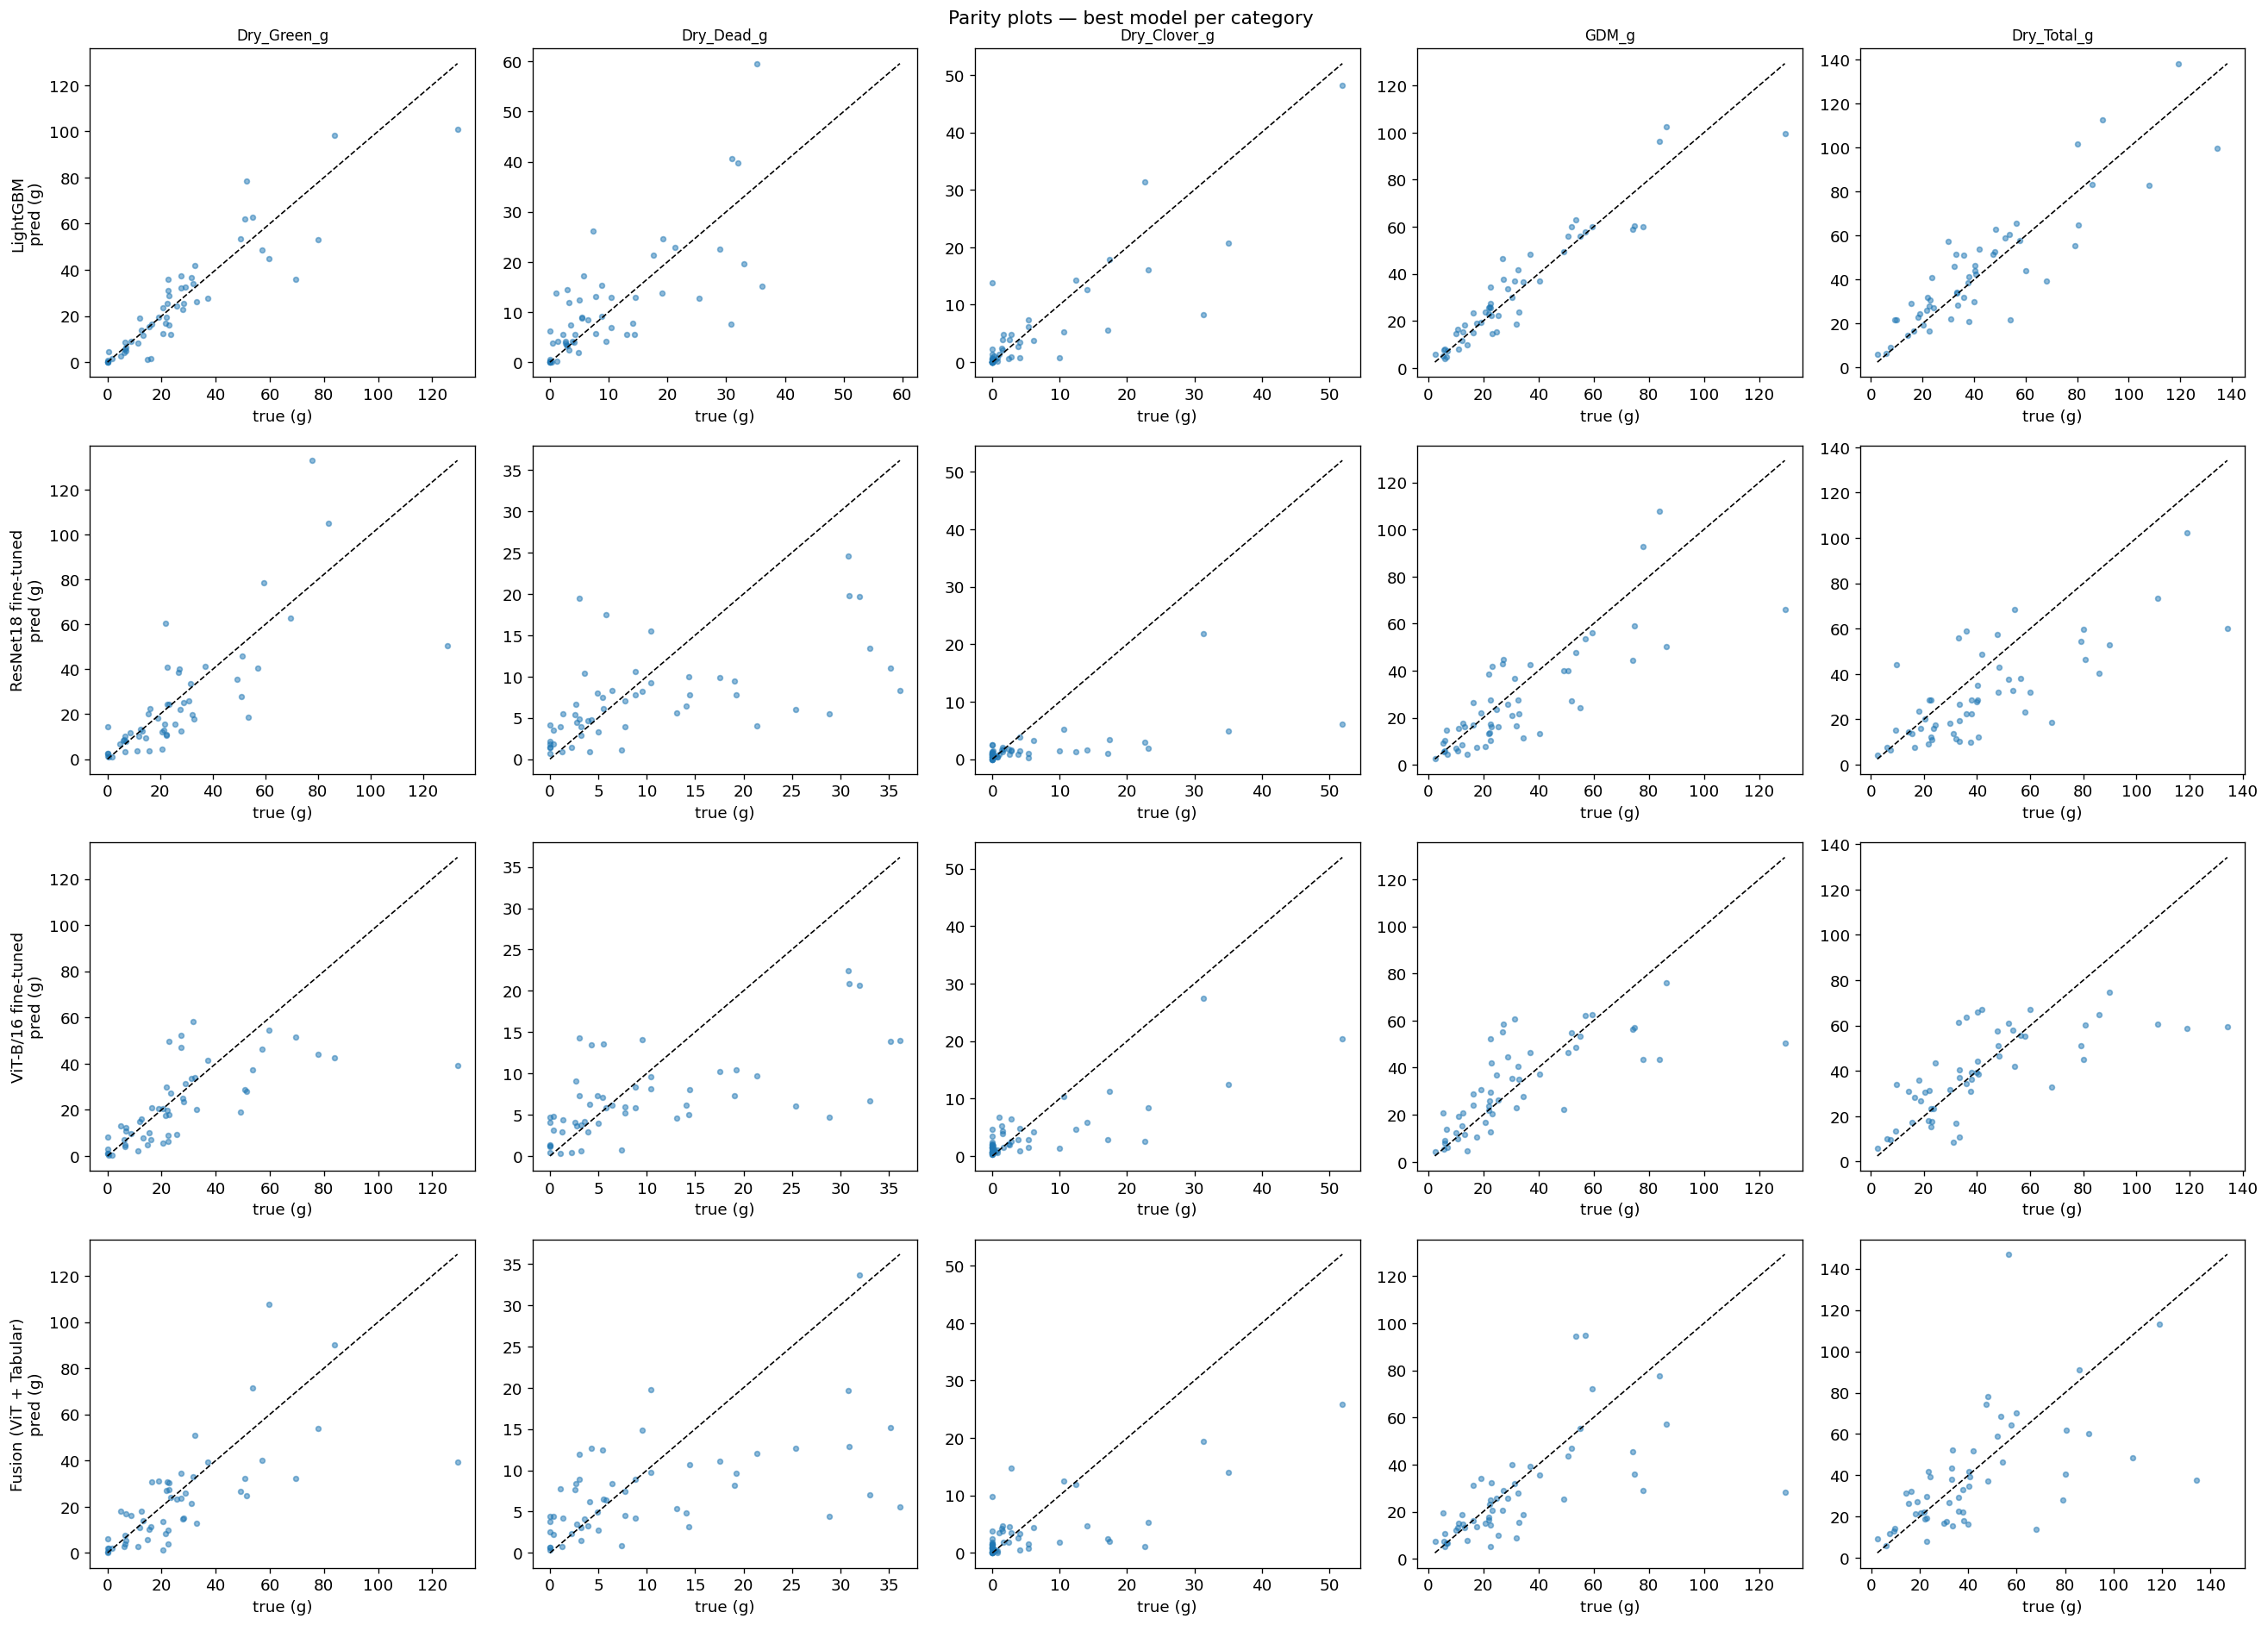

In [17]:
best_per_cat = {}
for label, res, cat in [("tabular", tabular_res, "Tabular"), ("cnn", cnn_res, "CNN"),
                         ("vit", vit_res, "ViT"), ("combined", combined_res, "Combined")]:
    if res is None: continue
    best_name, best_score = None, -float("inf")
    for name, data in res["models"].items():
        if "Ablation" in name: continue
        if data["test_weighted_r2"] > best_score and data.get("test_preds") is not None:
            best_name = name; best_score = data["test_weighted_r2"]
    if best_name:
        best_per_cat[cat] = (best_name, res["models"][best_name])

if best_per_cat:
    n_cats = len(best_per_cat)
    fig, all_axes = plt.subplots(n_cats, 5, figsize=(22, 4 * n_cats))
    if n_cats == 1: all_axes = [all_axes]

    for row, (cat, (name, data)) in enumerate(best_per_cat.items()):
        yt = data["test_true"]; yp = data["test_preds"]
        for k, (ax, t) in enumerate(zip(all_axes[row], TARGETS)):
            ax.scatter(yt[:, k], yp[:, k], s=12, alpha=0.5)
            lo = min(yt[:, k].min(), yp[:, k].min())
            hi = max(yt[:, k].max(), yp[:, k].max())
            ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
            if row == 0: ax.set_title(t, fontsize=10)
            ax.set_xlabel("true (g)")
            if k == 0: ax.set_ylabel(f"{name}\npred (g)")
    plt.suptitle("Parity plots — best model per category", fontsize=13)
    plt.tight_layout(); plt.show()

Qualitatively, we observe that for Dry_Clover_g, only the LightGBM model has reasonable correlation between its predictions and the true value of the target. Aside from that, Dry_Dead_g also appears to have lower correlation between predictions and the target than the remaining three targets.

## 8. Residual analysis

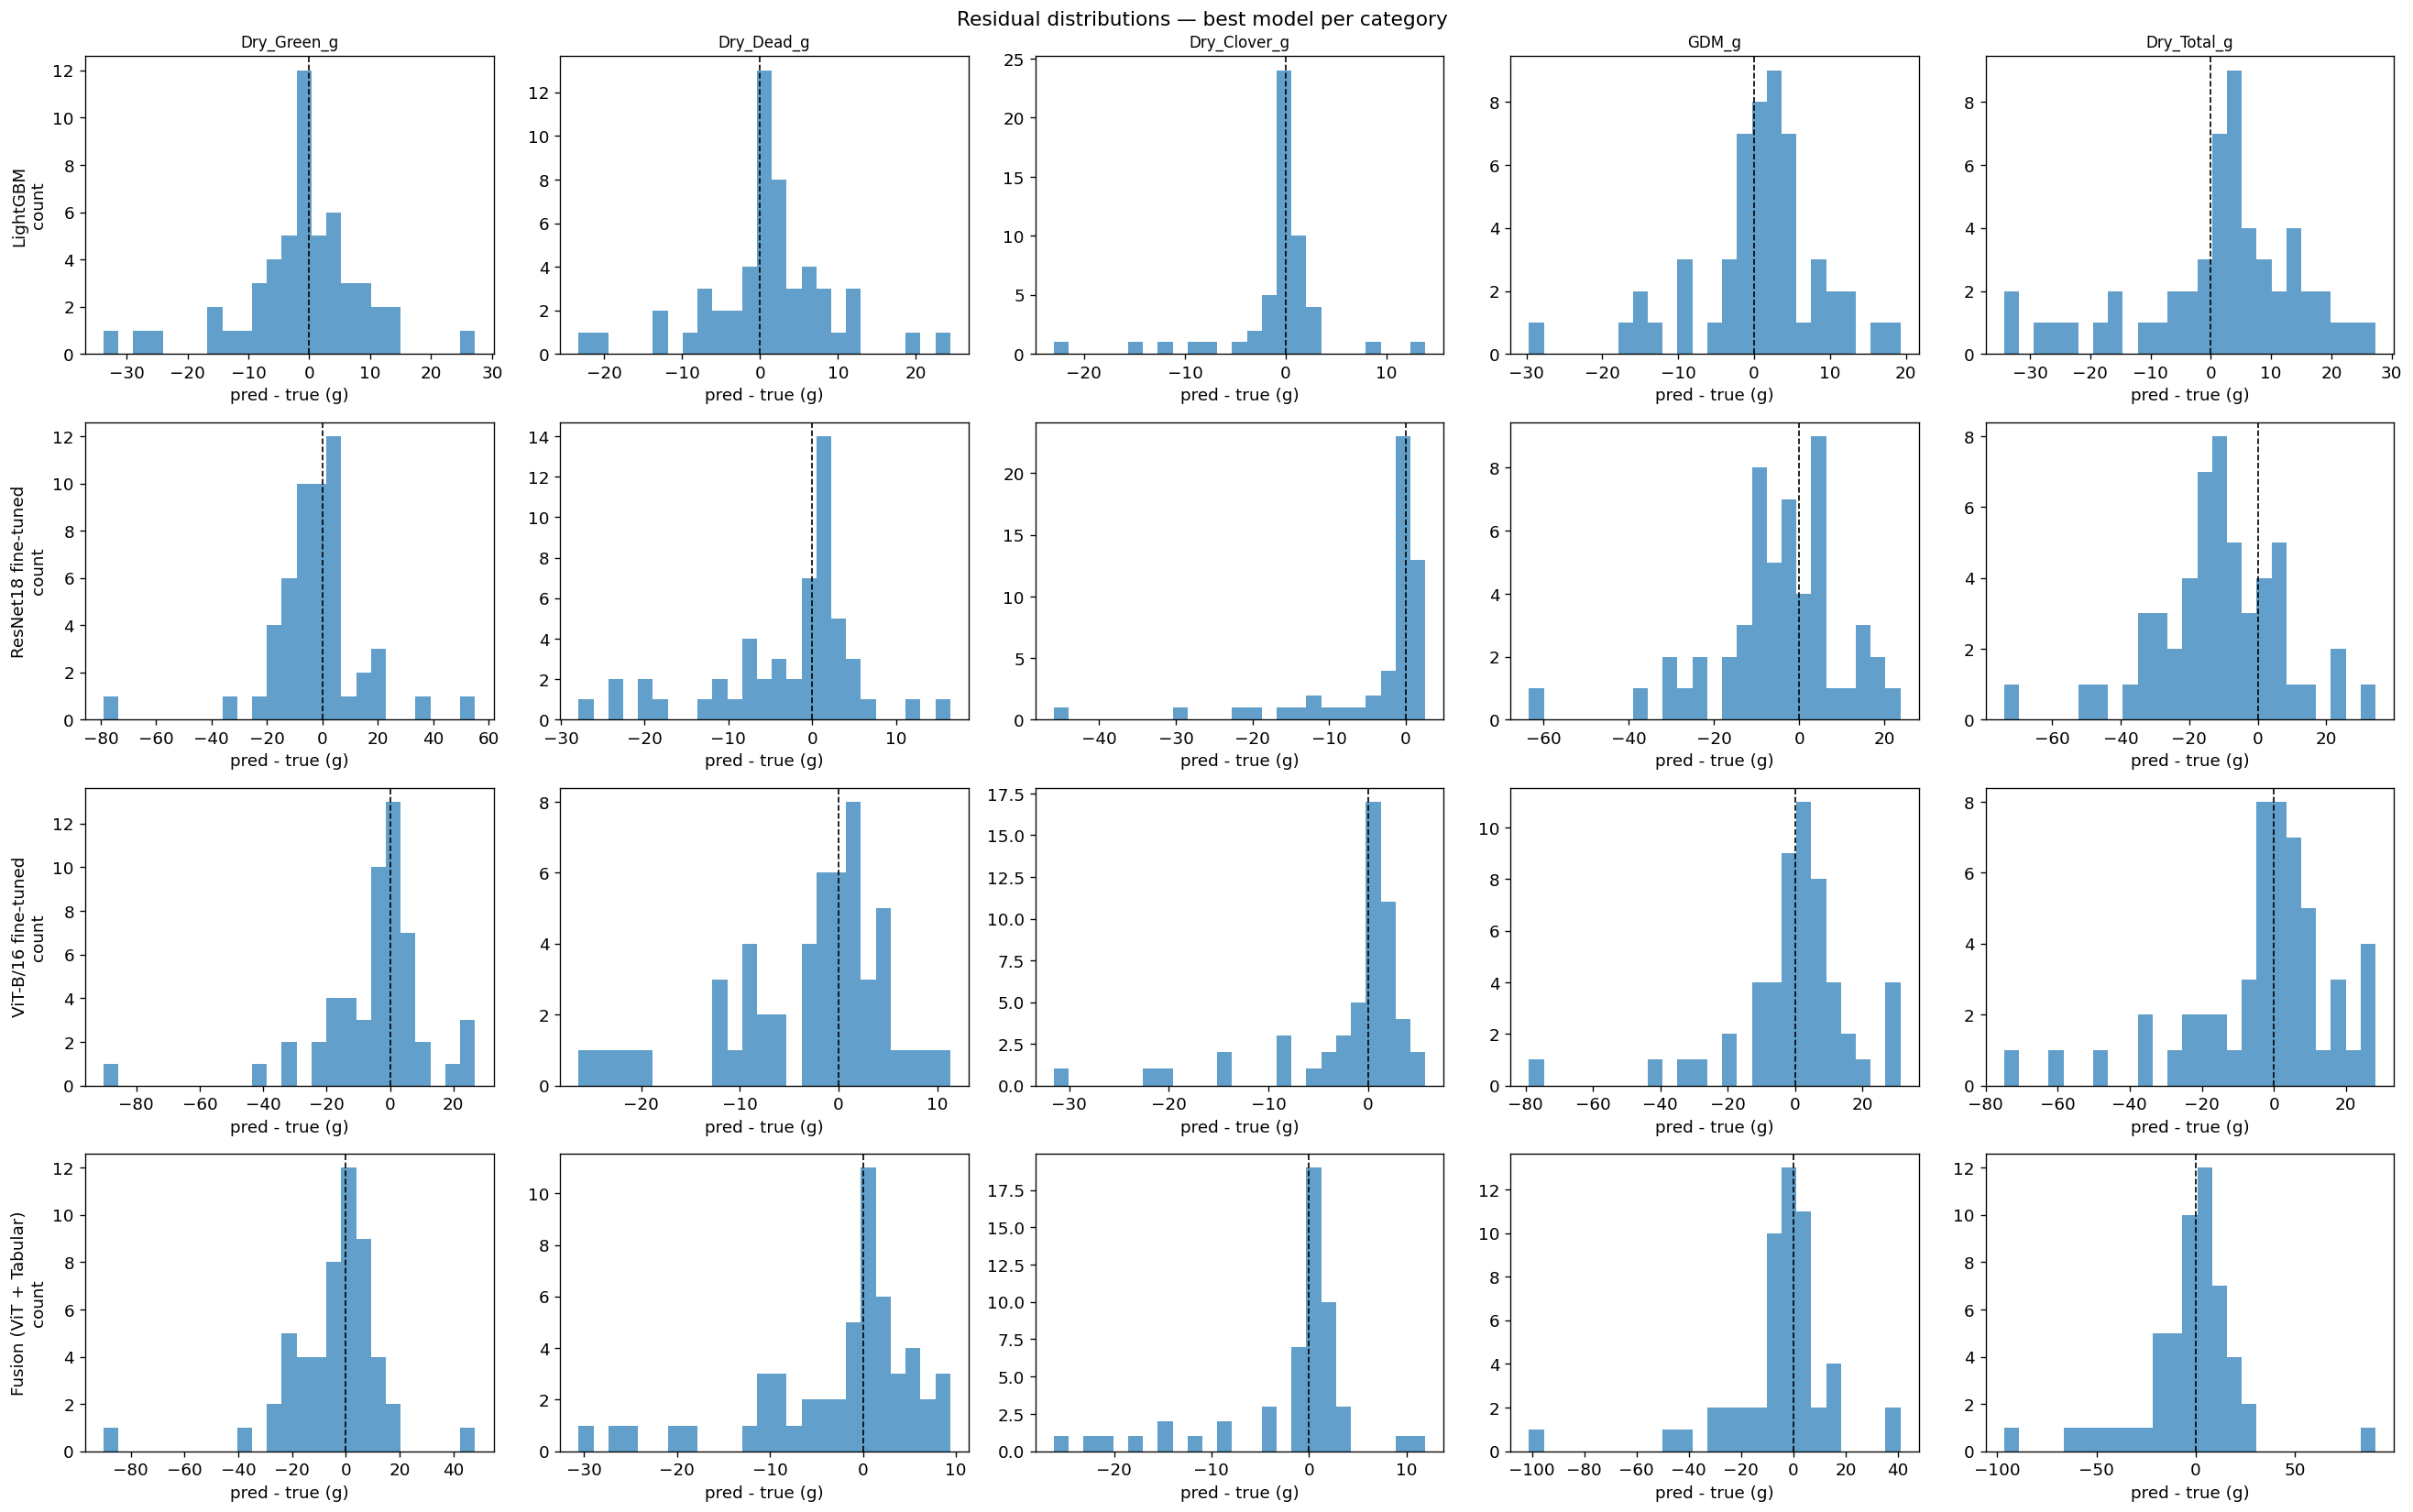

In [18]:
if best_per_cat:
    n_cats = len(best_per_cat)
    fig, all_axes = plt.subplots(n_cats, 5, figsize=(22, 3.5 * n_cats))
    if n_cats == 1: all_axes = [all_axes]

    for row, (cat, (name, data)) in enumerate(best_per_cat.items()):
        yt = data["test_true"]; yp = data["test_preds"]
        resid = yp - yt
        for k, (ax, t) in enumerate(zip(all_axes[row], TARGETS)):
            ax.hist(resid[:, k], bins=25, alpha=0.7)
            ax.axvline(0, color="k", linestyle="--", linewidth=1)
            ax.set_xlabel("pred - true (g)")
            if row == 0: ax.set_title(t, fontsize=10)
            if k == 0: ax.set_ylabel(f"{name}\ncount")
    plt.suptitle("Residual distributions — best model per category", fontsize=13)
    plt.tight_layout(); plt.show()

## 9. RMSE comparison table

In [19]:
rmse_rows = []
for label, res in [("tabular", tabular_res), ("cnn", cnn_res), ("vit", vit_res), ("combined", combined_res)]:
    if res is None: continue
    for name, data in res["models"].items():
        if "Ablation" in name: continue
        if data.get("test_preds") is not None and data.get("test_true") is not None:
            yt = data["test_true"]; yp = data["test_preds"]
            row = {"model": name}
            for k, t in enumerate(TARGETS):
                row[f"RMSE_{t}"] = np.sqrt(((yt[:, k] - yp[:, k]) ** 2).mean())
            row["RMSE_overall"] = np.sqrt(((yt - yp) ** 2).mean())
            rmse_rows.append(row)

if rmse_rows:
    rmse_df = pd.DataFrame(rmse_rows).sort_values("RMSE_overall")
    print(rmse_df.to_string(index=False))

                 model  RMSE_Dry_Green_g  RMSE_Dry_Dead_g  RMSE_Dry_Clover_g  RMSE_GDM_g  RMSE_Dry_Total_g  RMSE_overall
              LightGBM         10.235270         8.148312           5.098735    8.511739         13.658829      9.551609
    Ridge (alpha=0.01)         22.750780         9.026423           7.556760   14.363490         17.204046     15.221484
   ViT-B/16 fine-tuned         18.439613         8.804543           7.220167   17.534340         20.647236     15.514068
   ResNet18 fine-tuned         17.696667         9.133730           9.591576   15.801068         21.986109     15.631110
            Custom CNN         17.744982        10.123145          10.508498   18.951897         24.463009     17.236032
Fusion (ViT + Tabular)         18.504818         9.183715           7.552880   20.692469         26.090050     17.847599
            Custom ViT         21.309322         9.046915          10.672970   21.102942         23.983883     18.277893
     Constant Baseline         2

This results in essentially the same takeaways as we saw when comparing the validation R-squared across the different models in previous sections.

## 10. Failure case analysis

Top 10 worst predictions (ViT-B/16 fine-tuned):
  sample 46: weighted_RMSE=69.75, true_Total=134.2, pred_Total=59.4
  sample 38: weighted_RMSE=48.67, true_Total=119.1, pred_Total=58.7
  sample 50: weighted_RMSE=35.86, true_Total=108.0, pred_Total=60.7
  sample 17: weighted_RMSE=29.37, true_Total=80.2, pred_Total=45.1
  sample 30: weighted_RMSE=27.20, true_Total=79.1, pred_Total=51.2
  sample 1: weighted_RMSE=26.36, true_Total=68.1, pred_Total=33.0
  sample 0: weighted_RMSE=25.60, true_Total=33.0, pred_Total=61.2
  sample 42: weighted_RMSE=24.30, true_Total=35.9, pred_Total=63.8
  sample 41: weighted_RMSE=24.11, true_Total=40.3, pred_Total=66.0
  sample 29: weighted_RMSE=23.67, true_Total=41.9, pred_Total=67.1


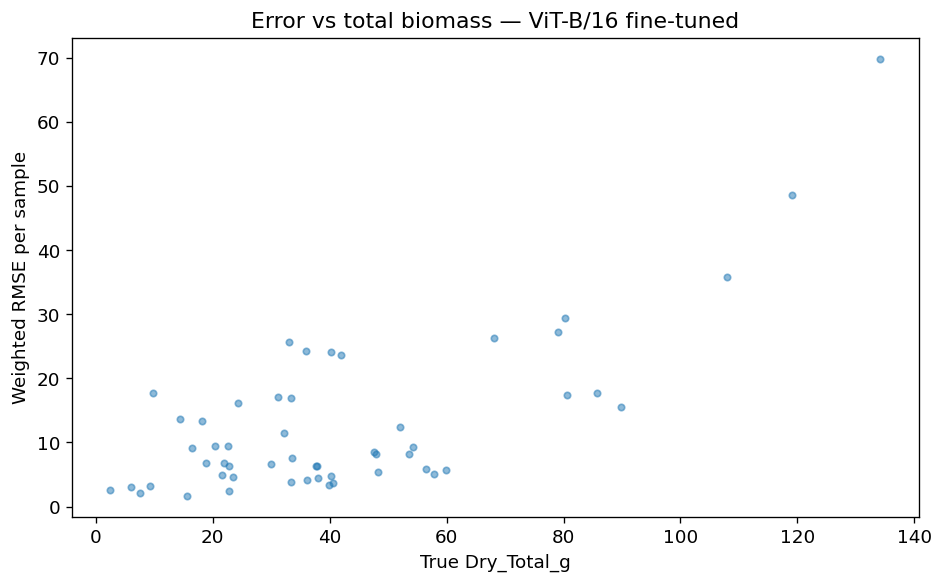

In [20]:
# Find best image-only model (submittable)
best_submit_name = None
best_submit_score = -float("inf")
best_submit_data = None

for label, res in [("cnn", cnn_res), ("vit", vit_res)]:
    if res is None: continue
    for name, data in res["models"].items():
        if data["test_weighted_r2"] > best_submit_score and data.get("test_preds") is not None:
            best_submit_name = name
            best_submit_score = data["test_weighted_r2"]
            best_submit_data = data

if best_submit_data:
    yt = best_submit_data["test_true"]; yp = best_submit_data["test_preds"]
    w_vec = np.array([TARGET_WEIGHTS[t] for t in TARGETS])
    sample_errors = np.sqrt((w_vec * (yt - yp) ** 2).sum(axis=1))

    worst_idx = np.argsort(sample_errors)[-10:][::-1]
    print(f"Top 10 worst predictions ({best_submit_name}):")
    for i in worst_idx:
        print(f"  sample {i}: weighted_RMSE={sample_errors[i]:.2f}, "
              f"true_Total={yt[i, 4]:.1f}, pred_Total={yp[i, 4]:.1f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(yt[:, 4], sample_errors, s=15, alpha=0.5)
    ax.set_xlabel("True Dry_Total_g"); ax.set_ylabel("Weighted RMSE per sample")
    ax.set_title(f"Error vs total biomass — {best_submit_name}")
    plt.tight_layout(); plt.show()

As one might expect, there appears to be a positive correlation in error size and the true value of the total targets. This follows in part due to the fact that being off by 10% on a target with an order of 100 results in a much higher absolute error than for a target with an order of 10.

## 11. Modality ablation summary

Modality ablation:
                 model  test_weighted_R2
Ablation: Tabular-only          0.690502
Fusion (ViT + Tabular)          0.394447
  Ablation: Image-only          0.346937


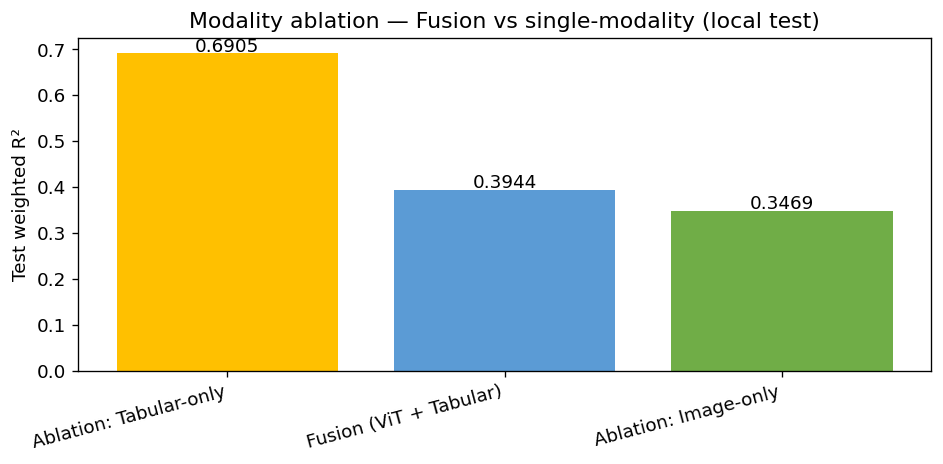

In [21]:
if combined_res:
    ablation_models = {name: data for name, data in combined_res["models"].items()}
    ablation_df = pd.DataFrame([
        {"model": name, "test_weighted_R2": data["test_weighted_r2"]}
        for name, data in ablation_models.items()
    ]).sort_values("test_weighted_R2", ascending=False)
    print("Modality ablation:")
    print(ablation_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(ablation_df["model"], ablation_df["test_weighted_R2"],
           color=["#FFC000", "#5B9BD5", "#70AD47"][:len(ablation_df)])
    ax.set_ylabel("Test weighted R²")
    ax.set_title("Modality ablation — Fusion vs single-modality (local test)")
    for i, v in enumerate(ablation_df["test_weighted_R2"]):
        ax.text(i, v + 0.005, f"{v:.4f}", ha="center")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout(); plt.show()

In this section, we run an Ablation study on the Fusion model to evaluate performance when the image portion was zeroed-out, when the tabular portion was zeroed-out, and when they were both used together. As we can see from its R-squared on our local test set, the Tabular-only model (ie: when we zeroed out the image contribution) far outpeforms the combination or Image-only model. From this, we can reasonably conclude that this architecture is inhibited from the inclusion of the vision model, which aligns with our prior findings on the tabular data models.

## 12. Final summary and conclusions

In [22]:
print("=" * 70)
print("FINAL MODEL COMPARISON — PASTURE BIOMASS PREDICTION")
print("=" * 70)
print()
print(summary_df[["model", "category", "test_weighted_R2", "can_submit"]].to_string(index=False))
print()

submittable = summary_df[summary_df["can_submit"]]
if len(submittable) > 0:
    best_sub = submittable.iloc[0]
    print(f"Best submittable model: {best_sub['model']} — R² = {best_sub['test_weighted_R2']:.4f}")

best_overall = summary_df.iloc[0]

FINAL MODEL COMPARISON — PASTURE BIOMASS PREDICTION

                 model              category  test_weighted_R2  can_submit
              LightGBM  Tabular (local only)          0.837255       False
    Ridge (alpha=0.01)  Tabular (local only)          0.674643       False
   ViT-B/16 fine-tuned                   ViT          0.589443        True
   ResNet18 fine-tuned                   CNN          0.565345        True
            Custom CNN                   CNN          0.458950        True
            Custom ViT                   ViT          0.436188        True
Fusion (ViT + Tabular) Combined (local only)          0.394447       False
     Constant Baseline  Tabular (local only)          0.212215       False

Best submittable model: ViT-B/16 fine-tuned — R² = 0.5894


Table formatting above created with the help of Generative AI.

Our main findings are as follows:


1.   Tabular features such as NVDI and Height are highly predictive of biomass when available, but are of course absent from the Kaggle test set.
2.   The fusion model was an attempt to combine modalities but ultimately performs worse than either of the modalities individually.
3.   Among the image-only models, we observed that transfer learning consistently outperformed training from scratch on this dataset, likely due to its limited size.
4.   We observed that the Dry_Dead_g target was the hardest to predict across essentially all models, while Dry_Clover_g was the most variable between them.
5.   If we had to submit today, the ViT would be the model of choice, since it only uses image data and performs better than comparable models (re: the ResNet18 transfer learning model) despite not using any tabular data.

